In [638]:
from numpy import array, zeros, where, arange, linspace, exp, sin, cos, sort, sum, dot, ndarray, random
from numpy.random import uniform, choice, seed
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

## Generate Fake Data

In [639]:
sigmoid = lambda x: 1 / (1 + exp(-x))
seed(42)

def f(x,y, lump = (1,1)):
    return 2*((sin(x/2) + sigmoid(x - 3)*2 + 5 + sin(x/4)) * 2 * exp(-.01*((x-lump[0])**2 + (y-lump[1])**2)))

In [640]:
num_samples = 10000

x = list(uniform(-20, 20, num_samples))
y = list(uniform(-20, 20, num_samples))

z = [f(i,j) for i,j in zip(x,y)]

In [641]:
df = pd.DataFrame({'x': x, 'y': y, 'z': z})
df.head()

,x,y,z
0,-5.018395,-5.054367,6.676236
1,18.028572,-6.683516,0.783200
2,9.279758,-12.953843,1.935567
3,3.946339,4.290667,26.970110
4,-13.759254,-0.935034,2.064458


### Where is the peak located?

Use this for testing the NN later

In [560]:
x_cen = 3.7
y_cen = .9
dist = .5
df[(df['x'] < x_cen + dist) &  (df['x'] > x_cen - dist) & (df['y'] < y_cen + dist) &  (df['y'] > y_cen - dist)]

,x,y,z
54,3.915999,0.997363,30.068825
496,3.346244,1.145194,29.933442
520,3.765229,1.367596,30.067172
961,4.126084,0.946896,29.925325
3648,3.876428,0.789699,30.070912
4224,3.325209,0.872628,29.916051
9960,3.523450,0.883352,30.055609


In [561]:
def plot_points(x, y, z, view_angle=-60, elevation=30):
    ax = plt.axes(projection='3d')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.azim = view_angle
    ax.elev = elevation
    ax.scatter(x, y, z, c=z, cmap='viridis', linewidth=0.5);

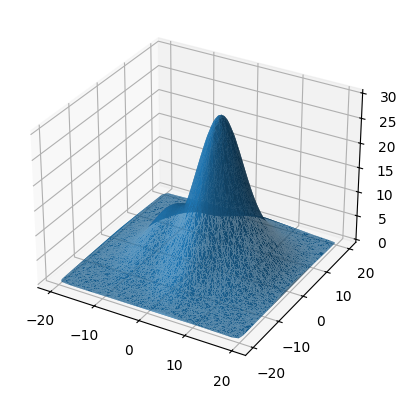

In [562]:
ax = plt.axes(projection='3d')
ax.plot_trisurf(x, y, z, linewidth=0.2, antialiased=True);

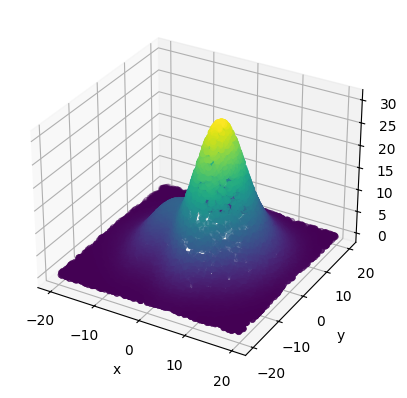

In [563]:
plot_points(x, y, z)

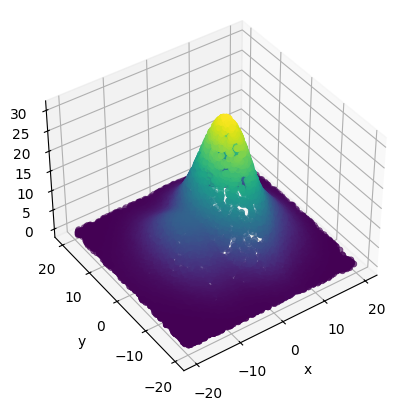

In [564]:
plot_points(x, y, z, -125, 40)

## Lets Build a Neural Network :)

Lets describe the equations! $\beta$ and $w$ are weights (bias and scalar respectively), $X = \{x_1, x_2, \ldots, x_p\}$ are the data for $p$ neurons in the previous layer, $A_{l,k}$ is the $k$th neuron in the $l$th hidden layer, $A_{l - 1, j}$ is the value of the jth neuron of the previous layer, $g(z)$ is the activation function, $f(x)$ is the output, and $N$ is the number of data points.
$$A_{l,k}(x) = g(\beta_{l,k} + \sum_{j=1}^pw_{l,k,j}A_{l - 1, j})$$

$f(x)$ is the same but with an extra bias term and sometimes without an activation function:
$$f_k(x) = \alpha_{final,k} + g(\beta_{l,k} + \sum_{j=1}^pw_{l,k,j}A_j)$$
$$f_k(x) = \beta_{l,k} + \sum_{j=1}^pw_{l,k,j}A_j$$

These functions describe the model but not how to *train* the model. Do do so, we need a loss function and backpropagation. We will be using L2 loss:
$$R(\theta) = \frac{1}{N}\sum^N_{i=1}(y - f_\theta(X_i))^2$$
$$\frac{\partial R}{\partial \theta_i} =  -2\sum^N_{i=1}(y - f_\theta(X_i))*\frac{\partial f_\theta(X_i)}{\partial \theta_i}$$
$$\frac{\partial f_\theta(X_i)}{\partial \theta_i} = \frac{\partial}{\partial \theta_i} (\alpha_{final,k} + g(\beta_{l,k} + \sum_{j=1}^pw_{l,k,j}A_j))$$

Backpropagation is simpler to compute the closer $\theta_i$ is to the output layer. The reason is that there are more functions that 

**Idea!! skipping optimizing along weights in earlier hidden layers could speed up time since they're more computationally intensive to compute**
**This likely WON'T save much time given that you use memoization to make the optimization of weights in earlier layers super fast. Probably not worth doing.**

### Backpropagation Pseudo-Code
For $A_{l,k}$, $\beta_{l,k}$, and $\omega_{l,k,j}$, l represents the layer, k represents the neuron within that layer, and j represents the neuron in the previous layer

def backpropagation(X = x values, $\hat{y}$ = observed y values):  
<div style="margin: 3px 0 0 20px;">
    - Goal: find weight values $\theta$ that minimize $\underset{\theta}{R(X)} = \frac{-1}{2}\sum_{i=1}^{N}(\hat{y} - f(X))^2$ </br>
    - $\forall \space \theta_i \in \{\beta_{0,0},\ldots,\beta_{l,k},\omega_{0,0,0},\ldots,\omega_{l,k,j}\}$ calculate:  
    <div style="margin: 3px 0 0 20px;">
        - $\frac{\partial R(X)}{\partial \theta_i} = \sum_{i=1}^N (\hat{y} - f(X))*f'(X)$
        - $\hat{y}$ and $f(X)$ should be stored/given
        - Calculate $f'(X)$ using the find_deriv function (pseudo-code below)
    </div>
</div>

#### find_deriv pseudo-code
def find_deriv(neuron, weight, omega = True):
<div style="margin: 3px 0 0 20px;">
    - check base case that neuron and weight are on same layer (calculate if so TODO) </br>
    - check base case that weight is one layer below neuron (calculate if so TODO) </br>
    - $f(x) = A_{l,k}(X) = g(\beta_{l,k} + \sum_{j=1}^pw_{l,k,j}A_{l - 1, j})$ </br>
    - so, we want to calculate sum([$\omega_{l,k,j} *$ find_deriv($A(X)$, weight) for A(X) in zip(weights, Activations in earlier layer]) </br>
    - this recursion should work
</div>



**What info do we *need*?**
1) How many hidden layers?
2) How many neurons in each layer?
3) Starting values for weights?

Lets say we have 
- 3 hidden layers

| Layer      | Neurons |
|------------|---------|
| Input      | 4       |
| 1st Hidden | 2       |
| 2nd Hidden | 8       |
| 3rd Hidden | 3       |
| Output     | 2       |

Each neuron in the input layer will have a bias weight and no scalar weights (**4 weights**). Each neuron in a hidden layer or output layer will have a bias weight and scalar weights for each neuron in the previous layer and the output layer will have an additional bias term ($2(1 + 4) + 8(1 + 2) + 3(1 + 8) + 2(2 + 3) = 10 + 24 + 27 + 10 = 71$ weights in the hidden and output layers).

In [629]:
class NeuralNetwork:
    '''
    This Class handles the construction, tuning, and use of a neural network.

    Intended Usage:
    model = NeuralNetwork()

    # Set the number of input neurons
    model.set_input_layer(num_neurons = 2)

    # Add hidden layer
    model.add_hidden_layer(num_neurons = 4)

    # set output layer
    model.set_output_layer(num_neurons = 1)

    # Initial prediction w/ random weights
    print(f'Model predicts: {model.forward_pass(test_data)}')

    # Train the model
    epochs = 1000
    for epoch in range(epochs):
        model.backpropagation(train_data)

    # Next prediction
    print(f'Model predicts: {model.forward_pass(test_data)}')
    '''

    def __relu(x):
      return x if x>0 else 0

    def __relu_deriv(x):
      return 1 if x>0 else 0

    # Constructor
    def __init__(self, input_neurons, def_weight_range = (-2,2)):
    # Class Properties
        self.bias_weights = list()
        self.scalar_weights = list()
        self.neuron_values = [zeros(input_neurons) - 1]
        self.deriv_values = list()
        self.act_funcs = list()
        self.final_biases = None
        self.def_weight_range = def_weight_range

    # Add Layers
    def add_layer(self, neurons, weights = None, act_func = __relu, act_func_deriv = __relu_deriv):
        num_last_layer = len(self.neuron_values[-1])
        if weights == None:
            self.bias_weights += [uniform(self.def_weight_range[0], self.def_weight_range[1], neurons)]
            self.scalar_weights += [uniform(self.def_weight_range[0], self.def_weight_range[1], (neurons, num_last_layer))]
            self.neuron_values += [zeros(neurons) - 1]
            self.deriv_values += [zeros(neurons)]
            self.act_funcs += [[act_func, act_func_deriv]]
        else:
            raise Exception("Strict assignment of weights not yet implemented")
        
    # set output layer
    def set_output_layer(self, neurons, weights = None, act_func = __relu, act_func_deriv = __relu_deriv):
        num_last_layer = len(self.neuron_values[-1])
        if weights == None:
            self.bias_weights += [uniform(self.def_weight_range[0], self.def_weight_range[1], neurons)]
            self.scalar_weights += [uniform(self.def_weight_range[0], self.def_weight_range[1], (neurons, num_last_layer))]
            self.neuron_values += [zeros(neurons) - 1]
            self.deriv_values += [zeros(neurons)]
            self.act_funcs += [[act_func, act_func_deriv]]
            self.final_biases = uniform(self.def_weight_range[0], self.def_weight_range[1], neurons)
        else: 
            raise Exception("Strict assignment of weights in layer initialization not yet implemented")

    def forward_pass(self, X):
        # Set up input
        self.neuron_values[0] = X

        # Calculate following layers
        for layer in range(1,len(self.neuron_values)):
            # List comprehension for each neuron in layer
            num_neurons = len(self.neuron_values[layer])
            new_values = array([self.calc_neuron((layer, neuron)) for neuron in range(num_neurons)])
            new_derivs = array([self.calc_neuron_deriv((layer, neuron)) for neuron in range(num_neurons)])
            self.neuron_values[layer] = new_values
            self.deriv_values[layer-1] = new_derivs
            
        self.neuron_values[-1] = self.neuron_values[-1] + self.final_biases
        return self.neuron_values[-1]

    # calculate value of neuron
    def calc_neuron(self, neuron):
        if neuron[0] == 0:
          raise Exception("Can only calculate hidden or output layers")
        layer = neuron[0]
        neuron = neuron[1]
        scalar_weights = self.scalar_weights[layer - 1][neuron]
        prev_values = self.neuron_values[layer - 1]
        act_func = self.act_funcs[layer-1][0]
        return act_func(self.bias_weights[layer - 1][neuron] + dot(prev_values, scalar_weights))

    def calc_neuron_deriv(self, neuron):
        if neuron[0] == 0:
          raise Exception("Can only calculate hidden or output layers")
        layer = neuron[0]
        neuron = neuron[1]
        scalar_weights = self.scalar_weights[layer - 1][neuron]
        prev_values = self.neuron_values[layer - 1]
        deriv = self.act_funcs[layer-1][1]
        return deriv(self.bias_weights[layer - 1][neuron] + dot(prev_values, scalar_weights))

    def __str__(self):
        print(f'Bias Weights: \n      {self.bias_weights}')
        print(f'Scalar Weights: \n      {self.scalar_weights}')
        print(f'Final Weights: \n      {self.final_biases}')
        print(f'Neuron Values: \n      {self.neuron_values}')
        print(f'Deriv Values: \n      {self.deriv_values}')
        return ""

    def set_training_data(self, x, y):
        if x.shape[1] != len(self.neuron_values[0]):
            raise Exception("Data and input layer have different dimensions!")
        y_output_size = 1 if len(y.shape) == 1 or y.shape[1] == 1 else y.shape[1]
        if y_output_size != len(self.neuron_values[-1]):
            raise Exception("Data and output layer have different dimensions!")
        if x.shape[0] != y.shape[0]:
            raise Exception("X and Y must be equal!")
        self.x_training = x
        self.y_training = y

    def backpropagation(self, learning_rate=0.001, batch=20, seed=42):
        num_layers = len(self.neuron_values)
        neurons_per_layer = [len(x) for x in self.neuron_values]
        LR = learning_rate / batch

        random.seed(seed)

        x_batch = self.x_training[choice(len(self.x_training), batch)]
        y_batch = self.y_training[choice(len(self.y_training), batch)]

        for X,Y in zip(x_batch, y_batch):
            
            # Calculate Neuron values and derivatives
            y_pred = self.forward_pass(X)

            # Get the difference between predicted and observed values
            R = (y_pred - Y) / batch
            
            # Final Biases
            self.final_biases += -1 * LR * R

            # Final Layer inner Biases
            self.bias_weights[-1] += -1 * LR * R * self.deriv_values[-1]

            # Scalar Weights
            if neurons_per_layer[-1] == 1:
                self.scalar_weights[-1] += -1 * LR * R * self.deriv_values[-1] * self.neuron_values[-2]
            else:
                # TODO following list comprehension is suspect
                self.scalar_weights[-1] += -1 * LR * R * array([self.deriv_values[-1][j] * self.neuron_values[-2] for j in range(neurons_per_layer[-1])])

            # Currently partial f / partial f hence an array of ones...
            pfpLast = zeros(neurons_per_layer[-1]) + 1

            # optimize hidden layer weights
            for layer in range(num_layers - 2, 0, -1):
                
                # partial DS layer / partial current layer Calculation - calculated for ea neuron in current layer
                pLastpAs = [self.deriv_values[layer] * self.scalar_weights[layer][:,neuron] for neuron in range(neurons_per_layer[layer])]

                # partial f(x) / partial current layer - calculated using dot(partial f / partial last, partial last / partial A)
                pfpAs = [dot(pfpLast, pLastpA) for pLastpA in pLastpAs]

                # update partial f(x) / partial US layer to match partial f(x) / partial current layer for next loop
                pfpLast = pfpAs

                # bias weights
                self.bias_weights[layer - 1] += -1 * LR * R * pfpAs * self.deriv_values[layer - 1]

                # scalar weights
                pfpOmegas = array([pfpAs[k] * self.deriv_values[layer-1][k] * self.neuron_values[layer-1] for k in range(neurons_per_layer[layer])])
                self.scalar_weights[layer - 1] += -1 * LR * R * pfpOmegas
    
    def set_scalar_weights(self, layer, weights):
        self.scalar_weights[layer - 1] = weights.astype(float)
    
    def set_bias_weights(self, layer, weights):
        self.bias_weights[layer - 1] = weights.astype(float)
    
    def set_final_biases(self, weights):
        self.final_biases = weights.astype(float)

    def rmse(self, batch = 10, seed=42):
        random.seed(seed)

        x_batch = self.x_training[choice(len(self.x_training), batch)]
        y_batch = self.y_training[choice(len(self.y_training), batch)]

        return (sum([(Y - self.forward_pass(X))**2 for X,Y in zip(x_batch, y_batch)], axis=0) / batch)**(1/2)


## Test Neural Network Framework

In [630]:
sigmoid = lambda x: 1 / (1 + exp(-x))
sigmoid_deriv = lambda x: sigmoid(x)*(1 - sigmoid(x))

In [631]:
test = NeuralNetwork(2, def_weight_range=(-10,10))
test.add_layer(3)
test.set_output_layer(1)

In [642]:
# Add training Data
input_data = array([x[:1000],y[:1000]]).T
test.set_training_data(x=input_data, y=array(z[:1000]))

#### Test Forward Pass

Make temporary training data

In [633]:
x = linspace(-10, 10, 21)
y = linspace(-10, 10, 21)
z = [f(i,j) for i,j in zip(x,y)]

test.set_training_data(array([x, y]).T, array(z))

Set specific weights

In [634]:
scalar_weights = [
    array([[1,-1], [-1,1], [1,0]]),
    array([[-1,1,-1]])
]
test.set_scalar_weights(1, scalar_weights[0])
test.set_scalar_weights(2, scalar_weights[1])

bias_weights = [
    array([3,2,1]),
    array([0.0])
]
test.set_bias_weights(1, bias_weights[0])
test.set_bias_weights(2, bias_weights[1])

final_weight = array([0.0])
test.set_final_biases(final_weight)

Test Forward Pass

In [635]:
test_input = [-4,-4]
test.forward_pass(test_input), test.neuron_values

(array([0.]), [[-4, -4], array([3., 2., 0.]), array([0.])])

**Forward Pass Looked good!**
|   X  | Correct f(X) | Returned f(X) |
| ---- | ------------ | ------------- |
|  1,2 |            0 |             0 |
|  2,0 |            0 |             0 |
| -3,1 |            6 |             6 |

#### Test Backpropagation

In [636]:
scalar_weights = [
    array([[1,-1], [-1,1], [1,0]]),
    array([[-1,1,-1]])
]
test.set_scalar_weights(1, scalar_weights[0])
test.set_scalar_weights(2, scalar_weights[1])

bias_weights = [
    array([3,2,1]),
    array([0.0])
]
test.set_bias_weights(1, bias_weights[0])
test.set_bias_weights(2, bias_weights[1])

final_weight = array([0.0])
test.set_final_biases(final_weight)

# Backprop
test.backpropagation(learning_rate=4, batch=4)

#### Test Repeated backpropagation

In [644]:
def act_func(x):
    return sin(x) / x
def act_func_deriv(x):
    return (cos(x) * x - sin(x)) / x**2

In [662]:
new_NN = NeuralNetwork(2, def_weight_range=(-10,10))
new_NN.add_layer(2)
new_NN.add_layer(5, act_func=act_func, act_func_deriv=act_func_deriv)
new_NN.set_output_layer(1, act_func=act_func, act_func_deriv=act_func_deriv)

# Add training Data
input_data = array([x[:1000],y[:1000]]).T
new_NN.set_training_data(x=input_data, y=array(z[:1000]))

In [687]:
init_rmse = new_NN.rmse(batch=40)
print(f'Initial RMSE: {init_rmse}')
random.seed(20)
epochseed = uniform(0, 100000, 30000).astype(int)
LR = .0075
for seed in epochseed:
    new_NN.backpropagation(learning_rate=LR, seed=seed, batch=5)
    LR = LR * .83
subs_rmse = new_NN.rmse(batch=40)
print(f'Subsequent RMSE: {subs_rmse}')
print(f'Error was {'increased' if init_rmse - subs_rmse < 0 else 'reduced'} by {abs(init_rmse - subs_rmse)}')

Initial RMSE: [6.4586762]
Subsequent RMSE: [6.457762]
Error was reduced by [0.0009142]


In [688]:
new_NN.forward_pass([10,10]), new_NN.forward_pass([x_cen, y_cen])

(array([4.03257915]), array([4.03324369]))

In [669]:
f(10,10), f(x_cen, y_cen)

(np.float64(5.254389176693529), np.float64(30.105202865138757))

In [318]:
z_pred = [test.forward_pass(input) for input in array([x,y]).T]
# plot_points(x, y, z_pred)
test.forward_pass([ -5.01839525,  -5.05436726])-test.forward_pass([ 18.02857226,  -6.68351615])

array([0.])

In [ ]:
test.forward_pass([10,10])

array([0.])